# 15 — Explainable AI (XAI)

This notebook provides visual explanations for predictions made by the
Lightweight Mel CNN.

Grad-CAM-style attribution is used to identify regions of the Log-Mel
spectrogram that contribute most strongly to a selected disease
prediction.

The objective is to investigate whether the model focuses on meaningful
time-frequency regions rather than treating the CNN as a completely
opaque classifier.

The best trained Lightweight Mel CNN from Notebook 11 is reused without
retraining.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

import torch
import torch.nn as nn

import soundfile as sf
import librosa
import librosa.display

print("Libraries imported.")

Libraries imported.


In [2]:
PROJECT_ROOT = Path(
    "/Users/vs/Sem 5/Respiratory-Disease-Classification"
)

DL_DIR = (
    PROJECT_ROOT /
    "data" /
    "processed" /
    "deep_learning"
)

CNN_BASELINE_DIR = (
    DL_DIR /
    "cnn_baseline"
)

XAI_DIR = (
    DL_DIR /
    "xai"
)

XAI_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("XAI output directory:")
print(XAI_DIR)

XAI output directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/xai


In [3]:
device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

class_mapping_df = pd.read_csv(
    DL_DIR /
    "disease_class_mapping.csv"
)

class_names = (
    class_mapping_df
    .sort_values("disease_label")["diagnosis"]
    .tolist()
)

num_classes = len(class_names)

print("Device:", device)
print("Classes:")

for i, name in enumerate(class_names):
    print(f"{i} -> {name}")

Device: mps
Classes:
0 -> Asthma
1 -> Bronchiectasis
2 -> Bronchiolitis
3 -> COPD
4 -> Healthy
5 -> LRTI
6 -> Pneumonia
7 -> URTI


In [4]:
class LightweightMelCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(
                1, 16,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                16, 32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(
                32, 64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.30),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [5]:
model_xai = LightweightMelCNN(
    num_classes=num_classes
).to(device)

checkpoint_path = (
    CNN_BASELINE_DIR /
    "best_lightweight_mel_cnn.pt"
)

checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

model_xai.load_state_dict(
    checkpoint["model_state_dict"]
)

model_xai.eval()

print("Model loaded successfully.")
print("Best epoch:", checkpoint["epoch"])
print("Validation loss:", checkpoint["val_loss"])
print("Validation accuracy:", checkpoint["val_accuracy"])

Model loaded successfully.
Best epoch: 32
Validation loss: 1.2070167528983018
Validation accuracy: 0.6159737417943107


In [6]:
normalization_df = pd.read_csv(
    DL_DIR /
    "logmel_train_normalization.csv"
)

logmel_mean = float(
    normalization_df.loc[
        normalization_df["statistic"] == "mean",
        "value"
    ].iloc[0]
)

logmel_std = float(
    normalization_df.loc[
        normalization_df["statistic"] == "std",
        "value"
    ].iloc[0]
)

print("Log-Mel mean:", logmel_mean)
print("Log-Mel std :", logmel_std)

Log-Mel mean: -66.74081420898438
Log-Mel std : 17.33708953857422


In [7]:
TARGET_SR = 4000
TARGET_SAMPLES = 20000

N_FFT = 512
HOP_LENGTH = 128
N_MELS = 64
FMIN = 0
FMAX = 2000


def fix_audio_length(signal, target_samples):

    if len(signal) < target_samples:

        signal = np.pad(
            signal,
            (
                0,
                target_samples - len(signal)
            ),
            mode="constant"
        )

    else:

        signal = signal[:target_samples]

    return signal.astype(np.float32)


def load_processed_audio(audio_path):

    signal, sr = sf.read(
        audio_path
    )

    if signal.ndim > 1:
        signal = np.mean(
            signal,
            axis=1
        )

    if sr != TARGET_SR:
        raise ValueError(
            f"Expected {TARGET_SR} Hz, got {sr} Hz"
        )

    return fix_audio_length(
        signal.astype(np.float32),
        TARGET_SAMPLES
    )


def extract_logmel(signal):

    mel_power = librosa.feature.melspectrogram(
        y=signal,
        sr=TARGET_SR,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS,
        fmin=FMIN,
        fmax=FMAX,
        power=2.0
    )

    mel_db = librosa.power_to_db(
        mel_power,
        ref=np.max
    )

    return mel_db.astype(
        np.float32
    )

In [8]:
test_manifest = pd.read_csv(
    CNN_BASELINE_DIR /
    "test_cnn_manifest.csv"
)

print(
    "Test cycles:",
    len(test_manifest)
)

print(
    "Test patients:",
    test_manifest["patient_id"].nunique()
)

Test cycles: 1561
Test patients: 25


In [9]:
predictions_df = pd.read_csv(
    CNN_BASELINE_DIR /
    "cnn_test_predictions.csv"
)

correct_predictions = predictions_df[
    predictions_df["true_label"]
    ==
    predictions_df["predicted_label"]
].copy()

print(
    "Correctly classified cycles:",
    len(correct_predictions)
)

print(
    correct_predictions[
        [
            "patient_id",
            "recording_id",
            "true_disease",
            "predicted_disease"
        ]
    ].head()
)

Correctly classified cycles: 1119
    patient_id recording_id true_disease predicted_disease
15         101          1b1         URTI              URTI
16         101          1b1         URTI              URTI
21         101          1b1         URTI              URTI
23         106          2b1         COPD              COPD
24         106          2b1         COPD              COPD


In [10]:
copd_correct = correct_predictions[
    correct_predictions["true_disease"] == "COPD"
]

if len(copd_correct) == 0:
    sample_row = correct_predictions.iloc[0]
else:
    sample_row = copd_correct.iloc[0]

print("Selected patient:", sample_row["patient_id"])
print("Recording:", sample_row["recording_id"])
print("True disease:", sample_row["true_disease"])
print("Predicted disease:", sample_row["predicted_disease"])

Selected patient: 106
Recording: 2b1
True disease: COPD
Predicted disease: COPD


In [11]:
audio_path = sample_row["audio_path"]

signal = load_processed_audio(
    audio_path
)

logmel = extract_logmel(
    signal
)

logmel_normalized = (
    logmel - logmel_mean
) / logmel_std

x_xai = torch.tensor(
    logmel_normalized,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0)

x_xai = x_xai.to(device)

print("Audio samples:", len(signal))
print("Log-Mel shape:", logmel.shape)
print("Model input:", x_xai.shape)

Audio samples: 20000
Log-Mel shape: (64, 157)
Model input: torch.Size([1, 1, 64, 157])


In [12]:
model_xai.eval()

with torch.no_grad():

    logits = model_xai(
        x_xai
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )[0]

predicted_label = int(
    probabilities.argmax().item()
)

predicted_probability = float(
    probabilities[predicted_label].item()
)

print(
    "True disease:",
    sample_row["true_disease"]
)

print(
    "Predicted disease:",
    class_names[predicted_label]
)

print(
    "Confidence:",
    f"{predicted_probability:.4f}"
)

print()
print("Class probabilities:")

for i, name in enumerate(class_names):

    print(
        f"{name}: "
        f"{probabilities[i].item():.4f}"
    )

True disease: COPD
Predicted disease: COPD
Confidence: 0.8593

Class probabilities:
Asthma: 0.0001
Bronchiectasis: 0.0968
Bronchiolitis: 0.0079
COPD: 0.8593
Healthy: 0.0110
LRTI: 0.0001
Pneumonia: 0.0132
URTI: 0.0116


In [13]:
activations = None
gradients = None


def forward_hook(
    module,
    input,
    output
):
    global activations
    activations = output


def backward_hook(
    module,
    grad_input,
    grad_output
):
    global gradients
    gradients = grad_output[0]


target_layer = model_xai.features[9]

forward_handle = target_layer.register_forward_hook(
    forward_hook
)

backward_handle = target_layer.register_full_backward_hook(
    backward_hook
)

print(
    "Target layer:",
    target_layer
)

Target layer: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)


In [14]:
model_xai.zero_grad()

logits = model_xai(
    x_xai
)

target_class = int(
    logits.argmax(
        dim=1
    ).item()
)

target_score = logits[
    0,
    target_class
]

target_score.backward()

print(
    "Target class:",
    target_class
)

print(
    "Activation shape:",
    activations.shape
)

print(
    "Gradient shape:",
    gradients.shape
)

Target class: 3
Activation shape: torch.Size([1, 64, 16, 39])
Gradient shape: torch.Size([1, 64, 16, 39])


In [15]:
feature_maps = activations[0]
feature_grads = gradients[0]

weights = feature_grads.mean(
    dim=(1, 2)
)

cam = torch.zeros(
    feature_maps.shape[1:],
    device=device
)

for channel in range(
    feature_maps.shape[0]
):
    cam += (
        weights[channel]
        * feature_maps[channel]
    )

cam = torch.relu(cam)

cam = cam.detach().cpu().numpy()

if cam.max() > 0:
    cam = (
        cam - cam.min()
    ) / (
        cam.max() - cam.min()
    )

print("Grad-CAM shape:", cam.shape)
print(
    "CAM range:",
    cam.min(),
    "to",
    cam.max()
)

Grad-CAM shape: (16, 39)
CAM range: 0.0 to 1.0


In [16]:
from scipy.ndimage import zoom

cam_resized = zoom(
    cam,
    (
        logmel.shape[0] / cam.shape[0],
        logmel.shape[1] / cam.shape[1]
    ),
    order=1
)

cam_resized = np.clip(
    cam_resized,
    0,
    1
)

print(
    "Original CAM shape:",
    cam.shape
)

print(
    "Log-Mel shape:",
    logmel.shape
)

print(
    "Resized CAM shape:",
    cam_resized.shape
)

print(
    "CAM range:",
    cam_resized.min(),
    "to",
    cam_resized.max()
)

Original CAM shape: (16, 39)
Log-Mel shape: (64, 157)
Resized CAM shape: (64, 157)
CAM range: 0.0 to 0.9850838


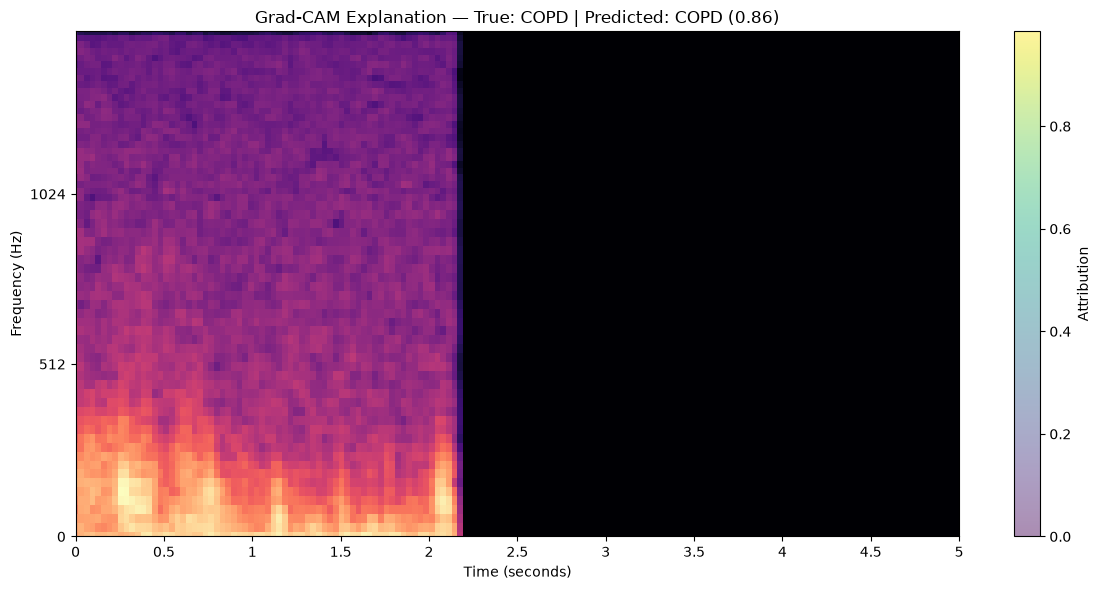

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/xai/gradcam_example.png


In [17]:
plt.figure(
    figsize=(12, 6)
)

librosa.display.specshow(
    logmel,
    sr=TARGET_SR,
    hop_length=HOP_LENGTH,
    x_axis="time",
    y_axis="mel",
    fmin=FMIN,
    fmax=FMAX
)

plt.imshow(
    cam_resized,
    aspect="auto",
    origin="lower",
    alpha=0.45,
    extent=[
        0,
        len(signal) / TARGET_SR,
        0,
        TARGET_SR / 2
    ]
)

plt.colorbar(
    label="Attribution"
)

plt.title(
    f"Grad-CAM Explanation — "
    f"True: {sample_row['true_disease']} | "
    f"Predicted: {class_names[predicted_label]} "
    f"({predicted_probability:.2f})"
)

plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()

xai_plot_path = (
    XAI_DIR /
    "gradcam_example.png"
)

plt.savefig(
    xai_plot_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    xai_plot_path
)

In [18]:
forward_handle.remove()
backward_handle.remove()

print("Grad-CAM hooks removed.")

Grad-CAM hooks removed.


In [19]:
xai_metadata = {
    "patient_id": int(sample_row["patient_id"]),
    "recording_id": str(sample_row["recording_id"]),
    "true_disease": str(sample_row["true_disease"]),
    "predicted_disease": str(
        class_names[predicted_label]
    ),
    "predicted_label": predicted_label,
    "predicted_probability": predicted_probability,
    "logmel_shape": list(logmel.shape),
    "gradcam_shape": list(cam.shape),
    "resized_gradcam_shape": list(
        cam_resized.shape
    ),
    "model": "Lightweight Mel CNN",
    "explanation_method": "Grad-CAM"
}

metadata_path = (
    XAI_DIR /
    "gradcam_example_metadata.json"
)

with open(
    metadata_path,
    "w"
) as f:
    json.dump(
        xai_metadata,
        f,
        indent=2
    )

print(
    "Saved:",
    metadata_path
)

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/xai/gradcam_example_metadata.json


In [20]:
correct_predictions = predictions_df[
    predictions_df["true_label"]
    ==
    predictions_df["predicted_label"]
].copy()

print(
    "Correctly classified cycles:",
    len(correct_predictions)
)

print()
print(
    correct_predictions["true_disease"]
    .value_counts()
)

Correctly classified cycles: 1119

true_disease
COPD              1082
Pneumonia           12
Bronchiolitis        9
Healthy              8
URTI                 5
Bronchiectasis       3
Name: count, dtype: int64


In [21]:
selected_examples = []

for disease in class_names:

    disease_examples = correct_predictions[
        correct_predictions["true_disease"]
        == disease
    ]

    if len(disease_examples) > 0:

        selected_examples.append(
            disease_examples.iloc[0]
        )

selected_examples_df = pd.DataFrame(
    selected_examples
)

print(
    "Selected examples:",
    len(selected_examples_df)
)

print(
    selected_examples_df[
        [
            "patient_id",
            "recording_id",
            "true_disease",
            "predicted_disease"
        ]
    ].to_string(index=False)
)

Selected examples: 6
 patient_id recording_id   true_disease predicted_disease
        169          1b2 Bronchiectasis    Bronchiectasis
        161          1b1  Bronchiolitis     Bronchiolitis
        106          2b1           COPD              COPD
        121          1b1        Healthy           Healthy
        122          2b1      Pneumonia         Pneumonia
        101          1b1           URTI              URTI


In [22]:
def generate_gradcam(
    model,
    x,
    target_class
):

    activations = None
    gradients = None

    def forward_hook(
        module,
        input,
        output
    ):
        nonlocal activations
        activations = output

    def backward_hook(
        module,
        grad_input,
        grad_output
    ):
        nonlocal gradients
        gradients = grad_output[0]

    target_layer = model.features[9]

    forward_handle = (
        target_layer.register_forward_hook(
            forward_hook
        )
    )

    backward_handle = (
        target_layer.register_full_backward_hook(
            backward_hook
        )
    )

    model.zero_grad()

    logits = model(x)

    target_score = logits[
        0,
        target_class
    ]

    target_score.backward()

    feature_maps = activations[0]
    feature_grads = gradients[0]

    weights = feature_grads.mean(
        dim=(1, 2)
    )

    cam = torch.zeros(
        feature_maps.shape[1:],
        device=device
    )

    for channel in range(
        feature_maps.shape[0]
    ):

        cam += (
            weights[channel]
            *
            feature_maps[channel]
        )

    cam = torch.relu(cam)

    cam = cam.detach().cpu().numpy()

    if cam.max() > 0:

        cam = (
            cam - cam.min()
        ) / (
            cam.max() - cam.min()
        )

    cam_resized = zoom(
        cam,
        (
            logmel.shape[0] / cam.shape[0],
            logmel.shape[1] / cam.shape[1]
        ),
        order=1
    )

    cam_resized = np.clip(
        cam_resized,
        0,
        1
    )

    forward_handle.remove()
    backward_handle.remove()

    return (
        cam,
        cam_resized,
        logits.detach()
    )

In [23]:
example = selected_examples_df.iloc[0]

signal = load_processed_audio(
    example["audio_path"]
)

logmel = extract_logmel(
    signal
)

logmel_normalized = (
    logmel - logmel_mean
) / logmel_std

x_example = torch.tensor(
    logmel_normalized,
    dtype=torch.float32
).unsqueeze(0).unsqueeze(0).to(device)

target_class = int(
    example["predicted_label"]
)

cam_raw, cam_resized, logits = (
    generate_gradcam(
        model_xai,
        x_example,
        target_class
    )
)

print(
    "Disease:",
    example["true_disease"]
)

print(
    "Raw CAM:",
    cam_raw.shape
)

print(
    "Resized CAM:",
    cam_resized.shape
)

Disease: Bronchiectasis
Raw CAM: (16, 39)
Resized CAM: (64, 157)


In [24]:
generated_xai_records = []

for _, example in selected_examples_df.iterrows():

    signal = load_processed_audio(
        example["audio_path"]
    )

    logmel = extract_logmel(
        signal
    )

    logmel_normalized = (
        logmel - logmel_mean
    ) / logmel_std

    x_example = torch.tensor(
        logmel_normalized,
        dtype=torch.float32
    ).unsqueeze(0).unsqueeze(0).to(device)

    predicted_label = int(
        example["predicted_label"]
    )

    with torch.no_grad():

        logits_check = model_xai(
            x_example
        )

        probabilities = torch.softmax(
            logits_check,
            dim=1
        )[0]

        confidence = float(
            probabilities[
                predicted_label
            ].item()
        )

    cam_raw, cam_resized, _ = (
        generate_gradcam(
            model_xai,
            x_example,
            predicted_label
        )
    )

    disease_name = str(
        example["true_disease"]
    )

    safe_name = (
        disease_name
        .lower()
        .replace(" ", "_")
    )

    output_path = (
        XAI_DIR /
        f"gradcam_{safe_name}.png"
    )

    plt.figure(
        figsize=(12, 6)
    )

    librosa.display.specshow(
        logmel,
        sr=TARGET_SR,
        hop_length=HOP_LENGTH,
        x_axis="time",
        y_axis="mel",
        fmin=FMIN,
        fmax=FMAX
    )

    plt.imshow(
        cam_resized,
        aspect="auto",
        origin="lower",
        alpha=0.45,
        extent=[
            0,
            len(signal) / TARGET_SR,
            0,
            TARGET_SR / 2
        ]
    )

    plt.colorbar(
        label="Attribution"
    )

    plt.title(
        f"{disease_name} — "
        f"Predicted: {class_names[predicted_label]} "
        f"(confidence={confidence:.2f})"
    )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Frequency (Hz)")

    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight"
    )

    plt.close()

    generated_xai_records.append({
        "patient_id": int(
            example["patient_id"]
        ),
        "recording_id": str(
            example["recording_id"]
        ),
        "true_disease": disease_name,
        "predicted_disease": class_names[
            predicted_label
        ],
        "confidence": confidence,
        "gradcam_shape": str(
            cam_resized.shape
        ),
        "output_file": str(
            output_path
        )
    })

print(
    "Generated explanations:",
    len(generated_xai_records)
)

Generated explanations: 6


In [25]:
xai_summary_df = pd.DataFrame(
    generated_xai_records
)

xai_summary_path = (
    XAI_DIR /
    "multi_class_xai_summary.csv"
)

xai_summary_df.to_csv(
    xai_summary_path,
    index=False
)

print(
    "Saved:",
    xai_summary_path
)

print(
    xai_summary_df
)

Saved: /Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/deep_learning/xai/multi_class_xai_summary.csv
   patient_id recording_id    true_disease predicted_disease  confidence  \
0         169          1b2  Bronchiectasis    Bronchiectasis    0.425009   
1         161          1b1   Bronchiolitis     Bronchiolitis    0.799746   
2         106          2b1            COPD              COPD    0.859301   
3         121          1b1         Healthy           Healthy    0.277485   
4         122          2b1       Pneumonia         Pneumonia    0.642409   
5         101          1b1            URTI              URTI    0.280307   

  gradcam_shape                                        output_file  
0     (64, 157)  /Users/vs/Sem 5/Respiratory-Disease-Classifica...  
1     (64, 157)  /Users/vs/Sem 5/Respiratory-Disease-Classifica...  
2     (64, 157)  /Users/vs/Sem 5/Respiratory-Disease-Classifica...  
3     (64, 157)  /Users/vs/Sem 5/Respiratory-Disease-Classifica...  
4  

## XAI Interpretation

Grad-CAM-style explanations were generated for correctly classified
test cycles across the disease classes for which the model produced
correct predictions.

The explanations highlight time-frequency regions that contributed
strongly to the CNN's selected class prediction.

The purpose of the analysis is to improve model interpretability and
investigate whether the CNN relies on localized regions of the
time-frequency representation.

The highlighted regions should be interpreted as model-attribution
regions rather than direct clinical evidence. Grad-CAM identifies
input regions influential to the model prediction, but it does not by
itself establish that a particular highlighted region corresponds to a
specific respiratory sound or pathological event.

Some disease classes may not have correctly classified examples in the
test set. Those classes are not artificially explained; instead, their
absence is documented as a limitation of the available test results.

The XAI analysis therefore complements the quantitative evaluation by
showing how the trained CNN uses the Log-Mel representation when making
individual predictions.